In [1]:
import mplsoccer as mpl
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Loading 2018 and 2022 world cup final
path2018 = "data/2018.json"
path2022 = "data/2022.json"

with open(path2018, 'r', encoding="utf8") as f: # add encoding helps to parse accents
    wc2018 = json.load(f)

test2018 = wc2018[0]
print(test2018.items())

dict_items([('id', '4a44199a-3111-4e28-b567-9c1393e68dff'), ('index', 1), ('period', 1), ('timestamp', '00:00:00.000'), ('minute', 0), ('second', 0), ('type', {'id': 35, 'name': 'Starting XI'}), ('possession', 1), ('possession_team', {'id': 771, 'name': 'France'}), ('play_pattern', {'id': 1, 'name': 'Regular Play'}), ('team', {'id': 771, 'name': 'France'}), ('duration', 0.0), ('tactics', {'formation': 442, 'lineup': [{'player': {'id': 3099, 'name': 'Hugo Lloris'}, 'position': {'id': 1, 'name': 'Goalkeeper'}, 'jersey_number': 1}, {'player': {'id': 5476, 'name': 'Benjamin Pavard'}, 'position': {'id': 2, 'name': 'Right Back'}, 'jersey_number': 2}, {'player': {'id': 5485, 'name': 'Raphaël Varane'}, 'position': {'id': 3, 'name': 'Right Center Back'}, 'jersey_number': 4}, {'player': {'id': 5492, 'name': 'Samuel Yves Umtiti'}, 'position': {'id': 5, 'name': 'Left Center Back'}, 'jersey_number': 5}, {'player': {'id': 5484, 'name': 'Lucas Hernández Pi'}, 'position': {'id': 6, 'name': 'Left Back'

In [3]:
print("Starting Lineup for France - " + str(test2018["tactics"]["formation"]))
lineups = test2018["tactics"]["lineup"]
for i in lineups:
    print(i["position"]["name"] + ": " + i["player"]["name"] + ", " + str(i["player"]["id"]))

Starting Lineup for France - 442
Goalkeeper: Hugo Lloris, 3099
Right Back: Benjamin Pavard, 5476
Right Center Back: Raphaël Varane, 5485
Left Center Back: Samuel Yves Umtiti, 5492
Left Back: Lucas Hernández Pi, 5484
Right Defensive Midfield: Paul Pogba, 20004
Left Defensive Midfield: N''Golo Kanté, 3961
Right Midfield: Kylian Mbappé Lottin, 3009
Left Midfield: Blaise Matuidi, 4375
Right Center Forward: Antoine Griezmann, 5487
Left Center Forward: Olivier Giroud, 3604


In [4]:
print("Starting Lineup for Croatia - " + str(wc2018[1]["tactics"]["formation"]))
croatiaLineup = wc2018[1]["tactics"]["lineup"]
for i in croatiaLineup:
    print(i["position"]["name"] + ": " + i["player"]["name"] + ", " + str(i["player"]["id"]))

Starting Lineup for Croatia - 433
Goalkeeper: Danijel Subašić, 3444
Right Back: Šime Vrsaljko, 5461
Right Center Back: Dejan Lovren, 3471
Left Center Back: Domagoj Vida, 5468
Left Back: Ivan Strinić, 5457
Center Defensive Midfield: Marcelo Brozović, 5469
Right Center Midfield: Luka Modrić, 5463
Left Center Midfield: Ivan Rakitić, 5470
Right Wing: Ante Rebić, 5465
Left Wing: Ivan Perišić, 5474
Center Forward: Mario Mandžukić, 5472


In [27]:
passes = []
for event in wc2018:
    if event["type"]["name"] == "Pass" and event["player"]["id"] == 3009:
        passes.append(event)
        
print(passes[0])
print("Num of passes: " + str(len(passes)))

{'id': '7963596f-b4fa-47fb-af93-391908841206', 'index': 139, 'period': 1, 'timestamp': '00:02:42.747', 'minute': 2, 'second': 42, 'type': {'id': 30, 'name': 'Pass'}, 'possession': 8, 'possession_team': {'id': 771, 'name': 'France'}, 'play_pattern': {'id': 4, 'name': 'From Throw In'}, 'team': {'id': 771, 'name': 'France'}, 'player': {'id': 3009, 'name': 'Kylian Mbappé Lottin'}, 'position': {'id': 12, 'name': 'Right Midfield'}, 'location': [74.0, 79.0], 'duration': 2.28, 'related_events': ['1e9da195-e897-4279-a9c4-b7fa654fec1a', 'ceaa5d40-13cb-48da-aa8e-ecfd7072ee7c'], 'pass': {'recipient': {'id': 5476, 'name': 'Benjamin Pavard'}, 'length': 12.649111, 'angle': -2.819842, 'height': {'id': 3, 'name': 'High Pass'}, 'end_location': [62.0, 75.0], 'type': {'id': 67, 'name': 'Throw-in'}, 'outcome': {'id': 9, 'name': 'Incomplete'}}}
Num of passes: 16


In [6]:
pass_coord = list(map(lambda event: event["location"], passes))
receive_coord = list(map(lambda event: event["pass"]["end_location"], passes))

In [7]:
print(pass_coord[0], receive_coord[0])

[74.0, 79.0] [62.0, 75.0]


In [8]:
x1, y1 = np.array(pass_coord).T
x2, y2 = np.array(receive_coord).T

In [9]:
print(x1, y1)
print(x2, y2)

[ 74.  12.  55.  45. 118.  67. 119.  81.  45. 116.  61.  82.  10.  35.
  86. 102.] [79. 64. 73. 63. 61. 79. 75. 73. 72. 57. 78. 78. 78. 49. 53.  3.]
[ 62.  40.  56.  29. 115.  70. 108.  76.  47. 111.  55.  65.  11.  39.
 108. 109.] [75. 80. 72. 54. 56. 71. 48. 59. 75. 45. 66. 77. 64. 49. 61. 44.]


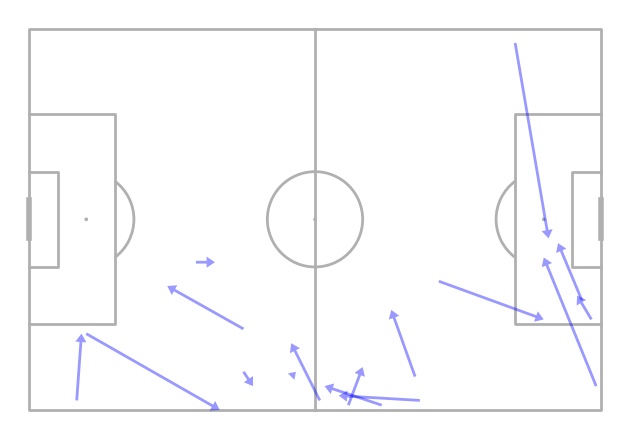

In [10]:
pitch = mpl.Pitch()
fig, ax = pitch.draw()

p = pitch.arrows(x1, y1, x2, y2, alpha=0.4, color="blue",
                 headaxislength=3, headlength=3, headwidth=4, width=2, ax=ax)

Attempting with pandas

In [11]:
import pandas as pd

df2018 = pd.read_json(path2018)

In [12]:
df2018.loc[0]["tactics"]

{'formation': 442,
 'lineup': [{'player': {'id': 3099, 'name': 'Hugo Lloris'},
   'position': {'id': 1, 'name': 'Goalkeeper'},
   'jersey_number': 1},
  {'player': {'id': 5476, 'name': 'Benjamin Pavard'},
   'position': {'id': 2, 'name': 'Right Back'},
   'jersey_number': 2},
  {'player': {'id': 5485, 'name': 'Raphaël Varane'},
   'position': {'id': 3, 'name': 'Right Center Back'},
   'jersey_number': 4},
  {'player': {'id': 5492, 'name': 'Samuel Yves Umtiti'},
   'position': {'id': 5, 'name': 'Left Center Back'},
   'jersey_number': 5},
  {'player': {'id': 5484, 'name': 'Lucas Hernández Pi'},
   'position': {'id': 6, 'name': 'Left Back'},
   'jersey_number': 21},
  {'player': {'id': 20004, 'name': 'Paul Pogba'},
   'position': {'id': 9, 'name': 'Right Defensive Midfield'},
   'jersey_number': 6},
  {'player': {'id': 3961, 'name': "N''Golo Kanté"},
   'position': {'id': 11, 'name': 'Left Defensive Midfield'},
   'jersey_number': 13},
  {'player': {'id': 3009, 'name': 'Kylian Mbappé Lot

In [13]:
df2018.head()

,id,index,period,timestamp,minute,second,type,possession,possession_team,play_pattern,...,dribble,foul_committed,foul_won,clearance,ball_recovery,injury_stoppage,shot,goalkeeper,block,substitution
0,4a44199a-3111-4e28-b567-9c1393e68dff,1,1,2025-12-23 00:00:00.000,0,0,"{'id': 35, 'name': 'Starting XI'}",1,"{'id': 771, 'name': 'France'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2137ed27-042c-4d73-877c-75d04406617c,2,1,2025-12-23 00:00:00.000,0,0,"{'id': 35, 'name': 'Starting XI'}",1,"{'id': 771, 'name': 'France'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,531c8cbd-7a3e-4e46-91c1-549a98c27bcb,3,1,2025-12-23 00:00:00.000,0,0,"{'id': 18, 'name': 'Half Start'}",1,"{'id': 771, 'name': 'France'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,9b9060d4-13a5-4a44-aafa-2221ed10a8bc,4,1,2025-12-23 00:00:00.000,0,0,"{'id': 18, 'name': 'Half Start'}",1,"{'id': 771, 'name': 'France'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6d7450f7-2590-4b04-a2ae-9ed11602e342,5,1,2025-12-23 00:00:00.400,0,0,"{'id': 30, 'name': 'Pass'}",2,"{'id': 785, 'name': 'Croatia'}","{'id': 9, 'name': 'From Kick Off'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
df2018.columns

Index(['id', 'index', 'period', 'timestamp', 'minute', 'second', 'type',
       'possession', 'possession_team', 'play_pattern', 'team', 'duration',
       'tactics', 'related_events', 'player', 'position', 'location', 'pass',
       'carry', 'under_pressure', 'ball_receipt', 'duel', 'counterpress',
       'interception', 'dribble', 'foul_committed', 'foul_won', 'clearance',
       'ball_recovery', 'injury_stoppage', 'shot', 'goalkeeper', 'block',
       'substitution'],
      dtype='object')

In [15]:
mbappePass = df2018[(df2018["player"] == {'id': 3009, 'name': 'Kylian Mbappé Lottin'}) &
                    (df2018["type"] == {'id': 30, 'name': 'Pass'})].reset_index()

In [16]:
passes = mbappePass["pass"]
passes

0     {'recipient': {'id': 5476, 'name': 'Benjamin P...
1     {'length': 32.24903, 'angle': 0.51914609999999...
2     {'length': 1.4142135, 'angle': -0.785398199999...
3     {'recipient': {'id': 5485, 'name': 'Raphaël Va...
4     {'recipient': {'id': 5487, 'name': 'Antoine Gr...
5     {'recipient': {'id': 5476, 'name': 'Benjamin P...
6     {'length': 29.15476, 'angle': -1.957672, 'heig...
7     {'recipient': {'id': 5487, 'name': 'Antoine Gr...
8     {'length': 3.6055512, 'angle': 0.98279375, 'he...
9     {'recipient': {'id': 5487, 'name': 'Antoine Gr...
10    {'recipient': {'id': 20004, 'name': 'Paul Pogb...
11    {'recipient': {'id': 5476, 'name': 'Benjamin P...
12    {'recipient': {'id': 5485, 'name': 'Raphaël Va...
13    {'length': 4.0, 'angle': 0.0, 'height': {'id':...
14    {'recipient': {'id': 20004, 'name': 'Paul Pogb...
15    {'recipient': {'id': 20004, 'name': 'Paul Pogb...
Name: pass, dtype: object

access values of dict inside dataframe is more difficult than lambda so I will stick with raw json

get mbappe pass map from 2022

In [17]:
with open(path2022, 'r', encoding="utf8") as f:
    wc2022 = json.load(f)

test2022 = wc2022[1]
print(test2022)

{'id': 'b32679f8-942e-4122-96a2-015caf75e628', 'index': 2, 'period': 1, 'timestamp': '00:00:00.000', 'minute': 0, 'second': 0, 'type': {'id': 35, 'name': 'Starting XI'}, 'possession': 1, 'possession_team': {'id': 779, 'name': 'Argentina'}, 'play_pattern': {'id': 1, 'name': 'Regular Play'}, 'team': {'id': 771, 'name': 'France'}, 'duration': 0.0, 'tactics': {'formation': 4231, 'lineup': [{'player': {'id': 3099, 'name': 'Hugo Lloris'}, 'position': {'id': 1, 'name': 'Goalkeeper'}, 'jersey_number': 1}, {'player': {'id': 4445, 'name': 'Jules Koundé'}, 'position': {'id': 2, 'name': 'Right Back'}, 'jersey_number': 5}, {'player': {'id': 5485, 'name': 'Raphaël Varane'}, 'position': {'id': 3, 'name': 'Right Center Back'}, 'jersey_number': 4}, {'player': {'id': 8519, 'name': 'Dayotchanculle Upamecano'}, 'position': {'id': 5, 'name': 'Left Center Back'}, 'jersey_number': 18}, {'player': {'id': 6704, 'name': 'Theo Bernard François Hernández'}, 'position': {'id': 6, 'name': 'Left Back'}, 'jersey_numb

In [18]:
print("Starting Lineup for France - " + str(test2022["tactics"]["formation"]))
lineups22 = test2022["tactics"]["lineup"]
for i in lineups22:
    print(i["position"]["name"] + ": " + i["player"]["name"] + ", " + str(i["player"]["id"]))

Starting Lineup for France - 4231
Goalkeeper: Hugo Lloris, 3099
Right Back: Jules Koundé, 4445
Right Center Back: Raphaël Varane, 5485
Left Center Back: Dayotchanculle Upamecano, 8519
Left Back: Theo Bernard François Hernández, 6704
Right Defensive Midfield: Aurélien Djani Tchouaméni, 10481
Left Defensive Midfield: Adrien Rabiot, 3026
Right Wing: Ousmane Dembélé, 5477
Center Attacking Midfield: Antoine Griezmann, 5487
Left Wing: Kylian Mbappé Lottin, 3009
Center Forward: Olivier Giroud, 3604


In [19]:
argTactic = wc2022[0]["tactics"]
print("Starting Lineup for Argentina - " + str(argTactic["formation"]))
argLineup = argTactic["lineup"]
for i in argLineup:
    print(i["position"]["name"] + ": " + i["player"]["name"] + ", " + str(i["player"]["id"]))

Starting Lineup for Argentina - 433
Goalkeeper: Damián Emiliano Martínez, 6909
Right Back: Nahuel Molina Lucero, 29201
Right Center Back: Cristian Gabriel Romero, 20572
Left Center Back: Nicolás Hernán Otamendi, 3090
Left Back: Nicolás Alejandro Tagliafico, 5507
Center Defensive Midfield: Enzo Fernandez, 38718
Right Center Midfield: Rodrigo Javier De Paul, 7797
Left Center Midfield: Alexis Mac Allister, 27886
Right Wing: Lionel Andrés Messi Cuccittini, 5503
Left Wing: Ángel Fabián Di María Hernández, 2995
Center Forward: Julián Álvarez, 29560


In [26]:
passes2022 = []
for event in wc2022:
    if event["type"]["name"] == "Pass" and event["player"]["id"] == 3009:
        passes2022.append(event)
        
print(passes2022[0])
print("Num of passes: " + str(len(passes2022)))

{'id': 'f56df973-fcb8-48e2-ae52-6d3e0506d84a', 'index': 166, 'period': 1, 'timestamp': '00:04:20.145', 'minute': 4, 'second': 20, 'type': {'id': 30, 'name': 'Pass'}, 'possession': 13, 'possession_team': {'id': 771, 'name': 'France'}, 'play_pattern': {'id': 1, 'name': 'Regular Play'}, 'team': {'id': 771, 'name': 'France'}, 'player': {'id': 3009, 'name': 'Kylian Mbappé Lottin'}, 'position': {'id': 21, 'name': 'Left Wing'}, 'location': [38.8, 46.8], 'duration': 1.193247, 'under_pressure': True, 'related_events': ['e0cd7a88-effa-4f19-bcf8-49e82880f000', 'eee5c376-d13b-4067-a0dc-38a7a9fb4ff1'], 'pass': {'recipient': {'id': 3026, 'name': 'Adrien Rabiot'}, 'length': 17.62328, 'angle': -1.9607861, 'height': {'id': 1, 'name': 'Ground Pass'}, 'end_location': [32.1, 30.5], 'body_part': {'id': 40, 'name': 'Right Foot'}}}
Num of passes: 27


In [21]:
pass_coord2022 = list(map(lambda event: event["location"], passes2022))
receive_coord2022 = list(map(lambda event: event["pass"]["end_location"], passes2022))

In [23]:
x1_2022, y1_2022 = np.array(pass_coord2022).T
x2_2022, y2_2022 = np.array(receive_coord2022).T

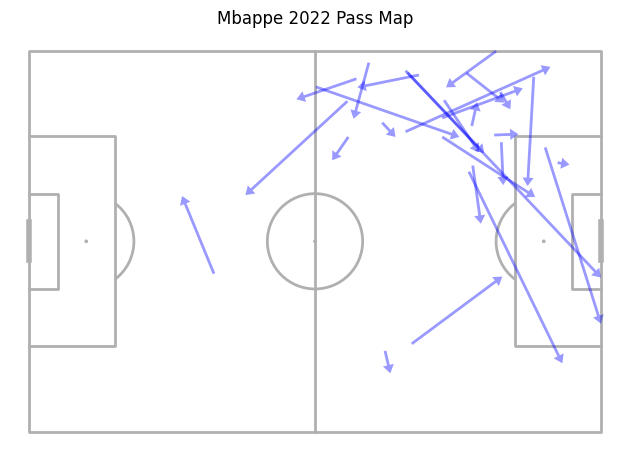

In [31]:
pitch2 = mpl.Pitch()
fig2, ax2 = pitch.draw()

p2 = pitch.arrows(x1_2022, y1_2022, x2_2022, y2_2022, alpha=0.4, color="blue",
                 headaxislength=3, headlength=3, headwidth=4, width=2, ax=ax2)
plt.title("Mbappe 2022 Pass Map")
plt.show()